# ETS Model Benchmark (Automatic Selection Only)

Parallel evaluation of ETS implementations with automatic component selection on M1, M3, and Tourism competition datasets.

**Packages evaluated:**
- **smooth** (ADAM, ES) - Automatic selection via Z (AIC-based)
- **statsforecast** - AutoETS (Nixtla)
- **sktime** - AutoETS
- **skforecast** - AutoETS

**Metrics:**
- RMSSE (Root Mean Squared Scaled Error)
- SAME (Scaled Absolute Mean Error)
- Computational time


In [1]:
import numpy as np
import pandas as pd
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import warnings
warnings.filterwarnings('ignore')

from fcompdata import M1, M3, Tourism

In [2]:
# Check which packages are available
from importlib.metadata import version as pkg_version
available_packages = {}

# Core environment (numpy/pandas affect every method's numeric backend)
import sys
print(f"python {sys.version.split()[0]}")
for _p in ('numpy', 'pandas'):
    print(f"{_p} v{pkg_version(_p)}")
print()

try:
    from smooth import ADAM, ES
    available_packages['smooth'] = True
    print(f"smooth v{pkg_version('smooth')}: Available")
except ImportError as e:
    available_packages['smooth'] = False
    print(f"smooth: Not available ({e})")

try:
    from statsforecast import models as sf_models
    available_packages['statsforecast'] = True
    print(f"statsforecast v{pkg_version('statsforecast')}: Available")
except ImportError as e:
    available_packages['statsforecast'] = False
    print(f"statsforecast: Not available ({e})")

try:
    from sktime.forecasting import ets as sktime_ets
    available_packages['sktime'] = True
    print(f"sktime v{pkg_version('sktime')}: Available")
except ImportError as e:
    available_packages['sktime'] = False
    print(f"sktime: Not available ({e})")

try:
    from skforecast.stats import Ets
    available_packages['skforecast'] = True
    print(f"skforecast v{pkg_version('skforecast')}: Available")
except ImportError as e:
    available_packages['skforecast'] = False
    print(f"skforecast: Not available ({e})")
try:
    from aeon.forecasting.stats import AutoETS as _AeonAutoETS
    available_packages['aeon'] = True
    print(f"aeon v{pkg_version('aeon')}: Available")
except ImportError as e:
    available_packages['aeon'] = False
    print(f"aeon: Not available ({e})")


python 3.14.4
numpy v2.3.5
pandas v2.3.3



smooth v1.0.7: Available


statsforecast v2.1.1: Available


sktime v1.0.1: Available
skforecast v0.23.0: Available
aeon v1.5.0: Available


## Error Metrics

In [3]:
def RMSSE(holdout, forecast, actuals):
    """
    Root Mean Squared Scaled Error.
    """
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)
    
    mse = np.mean((holdout - forecast) ** 2)
    scale = np.mean(np.diff(actuals) ** 2)
    
    if scale == 0:
        return np.nan
    
    return np.sqrt(mse / scale)

def SAME(holdout, forecast, actuals):
    """
    Scaled Absolute Mean Error.
    """
    holdout = np.asarray(holdout)
    forecast = np.asarray(forecast)
    actuals = np.asarray(actuals)
    
    ame = np.abs(np.mean(holdout - forecast))
    scale = np.mean(np.abs(np.diff(actuals)))
    
    if scale == 0:
        return np.nan
    
    return ame / scale

## Load Datasets

In [4]:
# Combine datasets into a list
datasets = []
for idx in M1.keys():
    datasets.append(M1[idx])
for idx in M3.keys():
    datasets.append(M3[idx])
for idx in Tourism.keys():
    datasets.append(Tourism[idx])

print(f"Total series: {len(datasets)}")
print(f"M1: {len(M1)} series")
print(f"M3: {len(M3)} series")
print(f"Tourism: {len(Tourism)} series")

Total series: 5315
M1: 1001 series
M3: 3003 series
Tourism: 1311 series


## Define Methods

Methods are defined as tuples: `(method_name, package, config_dict)`

In [5]:
# All method configurations (automatic selection only)
all_methods_config = [
    # smooth package - ADAM and ES models with automatic selection (Z = AIC-based)
    ("ADAM ETS Back", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "backcasting"}),
    ("ADAM ETS Opt", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "optimal"}),
    ("ADAM ETS Two", "smooth", {"class": "ADAM", "model": "ZXZ", "initial": "two-stage"}),
    ("ES Back", "smooth", {"class": "ES", "model": "ZXZ", "initial": "backcasting"}),
    ("ES Opt", "smooth", {"class": "ES", "model": "ZXZ", "initial": "optimal"}),
    ("ES Two", "smooth", {"class": "ES", "model": "ZXZ", "initial": "two-stage"}),
    ("ES XXX", "smooth", {"class": "ES", "model": "XXX", "initial": "backcasting"}),
    ("ES ZZZ", "smooth", {"class": "ES", "model": "ZZZ", "initial": "backcasting"}),
    ("ES FFF", "smooth", {"class": "ES", "model": "FFF", "initial": "backcasting"}),
    ("ES SXS", "smooth", {"class": "ES", "model": "SXS", "initial": "backcasting"}),

    # statsforecast - AutoETS (AIC-based selection)
    ("statsforecast AutoETS", "statsforecast", {}),

    # sktime - AutoETS (AIC-based selection)
    ("sktime AutoETS", "sktime", {}),

    # skforecast - Ets with automatic selection (ZZZ)
    ("skforecast AutoETS", "skforecast", {}),

    # aeon - AutoETS (AIC-based selection)
    ("aeon AutoETS", "aeon", {}),
]

# Filter to only available packages
methods_config = [
    (name, pkg, cfg) for name, pkg, cfg in all_methods_config 
    if available_packages.get(pkg, False)
]

methods_names = [m[0] for m in methods_config]
methods_number = len(methods_names)
dataset_length = len(datasets)

print(f"\nMethods available: {methods_number}")
print(f"Datasets: {dataset_length}")
print("\nMethod configurations:")
for name, pkg, cfg in methods_config:
    print(f"  {name} ({pkg})")


Methods available: 14
Datasets: 5315

Method configurations:
  ADAM ETS Back (smooth)
  ADAM ETS Opt (smooth)
  ADAM ETS Two (smooth)
  ES Back (smooth)
  ES Opt (smooth)
  ES Two (smooth)
  ES XXX (smooth)
  ES ZZZ (smooth)
  ES FFF (smooth)
  ES SXS (smooth)
  statsforecast AutoETS (statsforecast)
  sktime AutoETS (sktime)
  skforecast AutoETS (skforecast)
  aeon AutoETS (aeon)


## Evaluation Functions

Each package has a different API, so we need separate evaluation functions.

In [6]:
def _evaluate_task(args):
    """
    Worker function for parallel evaluation.
    Handles different package APIs (automatic selection models only).
    """
    import numpy as np
    import time
    import warnings
    warnings.filterwarnings('ignore')
    
    series_idx, series, method_name, package, config = args
    
    try:
        start_time = time.time()
        forecast_values = None
        
        # ===== SMOOTH PACKAGE =====
        if package == "smooth":
            from smooth import ADAM, ES
            
            model_class = config.get("class", "ES")
            model_str = config.get("model", "ZXZ")
            initial = config.get("initial", "backcasting")
            
            if series.period > 1:
                lags = [1, series.period]
            else:
                lags = [1]
                if len(model_str) == 3 and model_str[2] != 'N':
                    model_str = model_str[:2] + 'N'
            
            ModelClass = ADAM if model_class == "ADAM" else ES
            model = ModelClass(model=model_str, lags=lags, initial=initial)
            model.fit(series.x)
            forecasts = model.predict(h=series.h)
            forecast_values = forecasts['mean'].values
        
        # ===== STATSFORECAST =====
        elif package == "statsforecast":
            from statsforecast import models as sf_models
            
            season_length = series.period if series.period > 1 else 1
            model = sf_models.AutoETS(season_length=season_length)
            model.fit(series.x)
            forecasts = model.predict(h=series.h)
            forecast_values = forecasts['mean'] if isinstance(forecasts, dict) else forecasts
        
        # ===== SKTIME =====
        elif package == "sktime":
            import pandas as pd
            from sktime.forecasting import ets as sktime_ets

            y = pd.Series(series.x)
            fh = np.arange(1, series.h + 1)
            sp = series.period if series.period > 1 else 1
            model = sktime_ets.AutoETS(sp=sp, auto=True)
            model.fit(y)
            forecast_values = model.predict(fh).values

        # ===== SKFORECAST =====
        elif package == "skforecast":
            from skforecast.stats import Ets

            season_length = series.period if series.period > 1 else 1
            model = Ets(model="ZZZ", m=season_length)
            model.fit(series.x)
            forecast_values = model.predict(steps=series.h)

        # ===== AEON =====
        elif package == "aeon":
            from aeon.forecasting.stats import AutoETS

            season_length = series.period if series.period > 1 else 1
            model = AutoETS(seasonal_period=season_length)
            x = np.asarray(series.x, dtype=float)
            model.fit(x)
            forecast_values = model.iterative_forecast(x, prediction_horizon=series.h)

        else:
            raise ValueError(f"Unknown package: {package}")
        
        time_elapsed = time.time() - start_time
        
        forecast_values = np.asarray(forecast_values).flatten()[:series.h]
        
        # Calculate metrics
        mse = np.mean((series.xx - forecast_values) ** 2)
        scale = np.mean(np.diff(series.x) ** 2)
        rmsse = np.sqrt(mse / scale) if scale != 0 else np.nan
        
        ame = np.abs(np.mean(series.xx - forecast_values))
        scale_same = np.mean(np.abs(np.diff(series.x)))
        same = ame / scale_same if scale_same != 0 else np.nan
        
        return (series_idx, method_name, rmsse, same, time_elapsed)
    
    except Exception as e:
        return (series_idx, method_name, np.nan, np.nan, np.nan)


def evaluate_parallel(datasets, methods_config, n_workers=None):
    """
    Evaluate all methods on all datasets in parallel.
    """
    if n_workers is None:
        n_workers = multiprocessing.cpu_count()
    
    methods_names = [m[0] for m in methods_config]
    n_methods = len(methods_names)
    n_datasets = len(datasets)
    
    results = np.full((n_methods, n_datasets, 3), np.nan)
    
    tasks = []
    for method_name, package, config in methods_config:
        for i, series in enumerate(datasets):
            tasks.append((i, series, method_name, package, config))
    
    print(f"Starting parallel evaluation with {n_workers} workers...")
    print(f"Total tasks: {len(tasks)} ({n_methods} methods × {n_datasets} series)")
    
    start_time = time.time()
    completed = 0
    
    _ctx = multiprocessing.get_context("fork")
    with ProcessPoolExecutor(max_workers=n_workers, mp_context=_ctx) as executor:
        futures = {executor.submit(_evaluate_task, task): task for task in tasks}
        
        for future in as_completed(futures):
            result = future.result()
            series_idx, method_name, rmsse, same, elapsed = result
            
            method_idx = methods_names.index(method_name)
            results[method_idx, series_idx, 0] = rmsse
            results[method_idx, series_idx, 1] = same
            results[method_idx, series_idx, 2] = elapsed
            
            completed += 1
            if completed % 1000 == 0:
                elapsed_total = time.time() - start_time
                rate = completed / elapsed_total
                remaining = (len(tasks) - completed) / rate
                print(f"  Progress: {completed}/{len(tasks)} ({100*completed/len(tasks):.1f}%) - "
                      f"ETA: {remaining/60:.1f} min")
    
    total_time = time.time() - start_time
    print(f"\nCompleted in {total_time/60:.1f} minutes ({total_time:.1f}s)")
    print(f"Average time per task: {total_time/len(tasks)*1000:.1f}ms")
    
    return results

## Run Evaluation

In [7]:
print(f"Available CPU cores: {multiprocessing.cpu_count()}")

# The full 14-method evaluation (~25 min) is pre-computed and saved. Set
# RERUN=True to recompute (needs statsforecast/sktime/skforecast/aeon installed
# so every method is available); otherwise load the saved all-method results.
import os, datetime
RERUN = os.environ.get("BENCH_RERUN", "0") == "1"
_ncap = int(os.environ.get('BENCH_WORKERS', min(30, multiprocessing.cpu_count())))
date_str = datetime.datetime.now().strftime("%Y-%m-%d")

if RERUN:
    test_results = evaluate_parallel(datasets, methods_config, n_workers=_ncap)
    np.save(f'{date_str}-benchmark-ets-all.npy', test_results)
else:
    # All-method saved run. Names come from the UNFILTERED config so the summary
    # covers every approach (smooth vs statsforecast vs sktime/skforecast/aeon)
    # even when the competitor packages are not installed in this environment.
    test_results = np.load("2026-07-20-benchmark-ets-all.npy")
    methods_names = [m[0] for m in all_methods_config]
    methods_number = len(methods_names)

# Print summary
print("\nPer-method summary:")
for j, method in enumerate(methods_names):
    rmsse_mean = np.nanmean(test_results[j, :, 0])
    same_mean = np.nanmean(test_results[j, :, 1])
    time_mean = np.nanmean(test_results[j, :, 2])
    failed = np.sum(np.isnan(test_results[j, :, 0]))
    print(f"  {method:24s}: RMSSE={rmsse_mean:.4f}, SAME={same_mean:.4f}, "
          f"Time={time_mean:.3f}s, Failed={failed}")


Available CPU cores: 32

Per-method summary:
  ADAM ETS Back           : RMSSE=1.9530, SAME=1.9817, Time=0.103s, Failed=0
  ADAM ETS Opt            : RMSSE=1.9471, SAME=1.9648, Time=0.503s, Failed=0
  ADAM ETS Two            : RMSSE=1.9607, SAME=1.9902, Time=0.622s, Failed=0
  ES Back                 : RMSSE=1.9487, SAME=1.9735, Time=0.108s, Failed=0
  ES Opt                  : RMSSE=1.9467, SAME=1.9662, Time=0.502s, Failed=0
  ES Two                  : RMSSE=1.9574, SAME=1.9866, Time=0.614s, Failed=0
  ES XXX                  : RMSSE=1.9796, SAME=2.0161, Time=0.063s, Failed=0
  ES ZZZ                  : RMSSE=2.0543, SAME=2.1101, Time=0.176s, Failed=0
  ES FFF                  : RMSSE=2.0997, SAME=2.1737, Time=0.862s, Failed=0
  ES SXS                  : RMSSE=1.9619, SAME=1.9889, Time=0.299s, Failed=0
  statsforecast AutoETS   : RMSSE=1.9237, SAME=1.9387, Time=0.097s, Failed=0
  sktime AutoETS          : RMSSE=106608.6529, SAME=72714.2063, Time=1.082s, Failed=0
  skforecast AutoETS  

## Results Summary

In [8]:
import datetime
date_str = datetime.datetime.now().strftime('%Y-%m-%d')
test_results = np.load("2026-07-20-benchmark-ets-all.npy")
methods_names = [m[0] for m in all_methods_config]
methods_number = len(methods_names)

# Create RMSSE summary DataFrame (all series)
summary_rmsse = pd.DataFrame({
    'Method': methods_names,
    'Min': [np.nanmin(test_results[j, :, 0]) for j in range(methods_number)],
    'Q1': [np.nanquantile(test_results[j, :, 0], 0.25) for j in range(methods_number)],
    'Med': [np.nanmedian(test_results[j, :, 0]) for j in range(methods_number)],
    'Q3': [np.nanquantile(test_results[j, :, 0], 0.75) for j in range(methods_number)],
    'Max': [np.nanmax(test_results[j, :, 0]) for j in range(methods_number)],
    'Mean': [np.nanmean(test_results[j, :, 0]) for j in range(methods_number)],
    'Mean Time (s)': [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)],
    'Failed': [np.sum(np.isnan(test_results[j, :, 0])) for j in range(methods_number)]
})

print("\n" + "="*85)
print("EVALUATION RESULTS for RMSSE (All Series)")
print("="*85)
print(summary_rmsse.to_string(index=False))


EVALUATION RESULTS for RMSSE (All Series)
               Method      Min       Q1      Med       Q3          Max          Mean  Mean Time (s)  Failed
        ADAM ETS Back 0.018252 0.671249 1.187745 2.335668 5.161599e+01      1.953038       0.103247       0
         ADAM ETS Opt 0.024599 0.664326 1.186531 2.329918 5.161599e+01      1.947053       0.502612       0
         ADAM ETS Two 0.024599 0.669689 1.195231 2.368713 5.161599e+01      1.960704       0.621786       0
              ES Back 0.018252 0.674360 1.189752 2.312608 5.161599e+01      1.948698       0.108025       0
               ES Opt 0.024599 0.669326 1.183775 2.346949 5.161599e+01      1.946662       0.501539       0
               ES Two 0.024467 0.677858 1.196102 2.347646 5.161599e+01      1.957357       0.613954       0
               ES XXX 0.018252 0.685003 1.183571 2.326863 5.161599e+01      1.979638       0.063270       0
               ES ZZZ 0.011386 0.674360 1.196847 2.334080 1.154954e+02      2.054267       0.

In [9]:
# Create SAME summary DataFrame (all series)
summary_same = pd.DataFrame({
    'Method': methods_names,
    'Min': [np.nanmin(test_results[j, :, 1]) for j in range(methods_number)],
    'Q1': [np.nanquantile(test_results[j, :, 1], 0.25) for j in range(methods_number)],
    'Med': [np.nanmedian(test_results[j, :, 1]) for j in range(methods_number)],
    'Q3': [np.nanquantile(test_results[j, :, 1], 0.75) for j in range(methods_number)],
    'Max': [np.nanmax(test_results[j, :, 1]) for j in range(methods_number)],
    'Mean': [np.nanmean(test_results[j, :, 1]) for j in range(methods_number)],
    'Mean Time (s)': [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)],
    'Failed': [np.sum(np.isnan(test_results[j, :, 1])) for j in range(methods_number)]
})

print("\n" + "="*85)
print("EVALUATION RESULTS for SAME (All Series)")
print("="*85)
print(summary_same.to_string(index=False))


EVALUATION RESULTS for SAME (All Series)
               Method      Min       Q1      Med       Q3          Max         Mean  Mean Time (s)  Failed
        ADAM ETS Back 0.000261 0.378749 1.018707 2.435576 5.628198e+01     1.981727       0.103247       0
         ADAM ETS Opt 0.000569 0.364168 1.024559 2.467418 5.510179e+01     1.964838       0.502612       0
         ADAM ETS Two 0.000072 0.388245 1.036665 2.475049 5.510186e+01     1.990236       0.621786       0
              ES Back 0.000041 0.385218 1.033891 2.422379 5.651759e+01     1.973493       0.108025       0
               ES Opt 0.000067 0.370385 1.023623 2.461474 5.468603e+01     1.966217       0.501539       0
               ES Two 0.000519 0.393084 1.043207 2.486045 5.468558e+01     1.986586       0.613954       0
               ES XXX 0.000361 0.385912 1.029440 2.422823 5.442841e+01     2.016097       0.063270       0
               ES ZZZ 0.000041 0.397402 1.043831 2.470550 1.457005e+02     2.110125       0.175575    

In [10]:
# Create Time summary DataFrame (all series)
summary_time = pd.DataFrame({
    'Method': methods_names,
    'Min': [np.nanmin(test_results[j, :, 2]) for j in range(methods_number)],
    'Q1': [np.nanquantile(test_results[j, :, 2], 0.25) for j in range(methods_number)],
    'Med': [np.nanmedian(test_results[j, :, 2]) for j in range(methods_number)],
    'Q3': [np.nanquantile(test_results[j, :, 2], 0.75) for j in range(methods_number)],
    'Max': [np.nanmax(test_results[j, :, 2]) for j in range(methods_number)],
    'Mean': [np.nanmean(test_results[j, :, 2]) for j in range(methods_number)],
    'Total (min)': [np.nansum(test_results[j, :, 2]) / 60 for j in range(methods_number)],
    'Failed': [np.sum(np.isnan(test_results[j, :, 2])) for j in range(methods_number)]
})

print("\n" + "="*85)
print("EVALUATION RESULTS for Computational Time in seconds (All Series)")
print("="*85)
print(summary_time.to_string(index=False))


EVALUATION RESULTS for Computational Time in seconds (All Series)
               Method      Min       Q1      Med       Q3      Max     Mean  Total (min)  Failed
        ADAM ETS Back 0.006678 0.035371 0.082032 0.125757 0.688485 0.103247     9.145999       0
         ADAM ETS Opt 0.036717 0.200195 0.299995 0.737734 2.321976 0.502612    44.523003       0
         ADAM ETS Two 0.034665 0.244593 0.395871 0.952039 2.957522 0.621786    55.079896       0
              ES Back 0.006575 0.037068 0.083951 0.129956 0.697383 0.108025     9.569185       0
               ES Opt 0.035413 0.202473 0.300054 0.743728 2.290267 0.501539    44.427970       0
               ES Two 0.036478 0.243286 0.389454 0.944949 2.917220 0.613954    54.386115       0
               ES XXX 0.005937 0.028265 0.054014 0.082345 0.286650 0.063270     5.604624       0
               ES ZZZ 0.006273 0.038179 0.112648 0.209926 1.421632 0.175575    15.553028       0
               ES FFF 0.027729 0.196925 0.866187 1.284986 2.

## Series failed diagnostics

In [11]:
# Build series ID list matching the order in `datasets`
series_ids = list(M1.keys()) + list(M3.keys()) + list(Tourism.keys())
dataset_sizes = {"M1": len(M1), "M3": len(M3), "Tourism": len(Tourism)}
dataset_boundaries = {}
offset = 0
for name, size in dataset_sizes.items():
    dataset_boundaries[name] = (offset, offset + size)
    offset += size

print("=" * 70)
print("FAILED SERIES DIAGNOSTICS")
print("=" * 70)

any_failures = False
for j, method in enumerate(methods_names):
    failed_mask = np.isnan(test_results[j, :, 0])
    n_failed = failed_mask.sum()
    if n_failed == 0:
        continue
    any_failures = True
    failed_indices = np.where(failed_mask)[0]

    print(f"\n{method} ({n_failed} failures):")
    for ds_name, (lo, hi) in dataset_boundaries.items():
        ds_failed = [series_ids[i] for i in failed_indices if lo <= i < hi]
        if ds_failed:
            print(f"  {ds_name}: {', '.join(str(s) for s in ds_failed)}")

if not any_failures:
    print("\nNo failures detected.")

FAILED SERIES DIAGNOSTICS

No failures detected.


## Predictive Distribution Assessment (Pinball + Calibration)

Quantile forecasts at levels `seq(0.01, 0.99, 0.01)` (99 levels) for every method.
For each method we report:

- **Scaled pinball loss** per level (pinball averaged over the holdout horizon,
  divided by the in-sample scale `mean(|diff(train)|)` so it is comparable across
  series, like SAME), and its mean over all levels (≈ a scaled CRPS).
- **Calibration**: empirical coverage `P(y ≤ q_τ)` per level — the reliability curve
  vs the nominal level — and the **mean calibration error** `mean_τ |coverage_τ − τ|`.

Quantiles come from each package's native predictive distribution: smooth
`predict(interval="prediction", side="both")`, statsforecast `lo/hi` levels,
sktime `predict_quantiles`, skforecast `predict_interval`. **aeon has no quantile
API**, so its distributional metrics are `NaN`. Every quantile row is sorted
(monotone rearrangement) before scoring.

In [12]:
# Load the saved distributional results (shape: n_methods x n_series x 99 x 2;
# [...,0]=scaled pinball, [...,1]=coverage). The heavy run (~long) lives in
# run_dist_benchmark.py. Set BENCH_RERUN_DIST=1 to recompute it here.
import os, glob, subprocess, sys
quantile_levels = np.round(np.arange(0.01, 1.0, 0.01), 2)   # 99 levels
dist_methods = [m[0] for m in all_methods_config]           # all 14, config order

if os.environ.get("BENCH_RERUN_DIST", "0") == "1":
    subprocess.run([sys.executable, "run_dist_benchmark.py"], check=True)

_dist_files = sorted(glob.glob("*-benchmark-dist.npy"))
assert _dist_files, "no *-benchmark-dist.npy found; run run_dist_benchmark.py first"
dist_results = np.load(_dist_files[-1])                     # newest
print("loaded", _dist_files[-1], "shape", dist_results.shape)
assert dist_results.shape[0] == len(dist_methods) and dist_results.shape[2] == 99


loaded 2026-07-23-benchmark-dist.npy shape (14, 5315, 99, 2)


In [13]:
# Pinball + calibration summary (one row per method).
# Mean pinball is dominated by a few series where sktime/skforecast forecasts
# explode, so the robust Median (over series) pinball is reported alongside.
_pin = dist_results[:, :, :, 0]      # scaled pinball  (methods, series, 99)
_cov = dist_results[:, :, :, 1]      # coverage        (methods, series, 99)
_pin_series = np.nanmean(_pin, axis=2)   # (methods, series) mean over levels

rows = []
for j, name in enumerate(dist_methods):
    cov_curve = np.nanmean(_cov[j], axis=0)                 # (99,)
    if np.all(np.isnan(cov_curve)):
        rows.append({"Method": name, "Mean Pinball": np.nan, "Median Pinball": np.nan,
                     "MCE": np.nan, "Cov@0.1": np.nan, "Cov@0.5": np.nan,
                     "Cov@0.9": np.nan, "n (series)": 0})
        continue
    rows.append({"Method": name,
                 "Mean Pinball": np.nanmean(_pin[j]),
                 "Median Pinball": np.nanmedian(_pin_series[j]),
                 "MCE": np.nanmean(np.abs(cov_curve - quantile_levels)),
                 "Cov@0.1": cov_curve[9], "Cov@0.5": cov_curve[49], "Cov@0.9": cov_curve[89],
                 "n (series)": int(np.sum(~np.isnan(_pin_series[j])))})

summary_dist = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 100)
print("PREDICTIVE DISTRIBUTION: scaled pinball (lower=better) + calibration MCE (lower=better)")
print("Median pinball is robust to the sktime/skforecast forecast blow-ups that inflate the mean.")
print("=" * 100)
print(summary_dist.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



PREDICTIVE DISTRIBUTION: scaled pinball (lower=better) + calibration MCE (lower=better)
Median pinball is robust to the sktime/skforecast forecast blow-ups that inflate the mean.
               Method          Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9  n (series)
               ES XXX                0.8838          0.4894 0.0477   0.1301   0.4514   0.8161        5315
         ADAM ETS Opt                0.8571          0.5042 0.0500   0.1063   0.4352   0.8393        5315
        ADAM ETS Back                0.8626          0.5045 0.0526   0.1080   0.4286   0.8412        5315
         ADAM ETS Two                0.8621          0.5045 0.0522   0.1075   0.4315   0.8368        5315
       sktime AutoETS            22334.9594          0.5089 0.0490   0.1165   0.4380   0.8316        5315
               ES Opt                0.8484          0.5100 0.0413   0.0948   0.4499   0.8462        5315
statsforecast AutoETS                0.8495          0.5115 0.0422   0.1029   

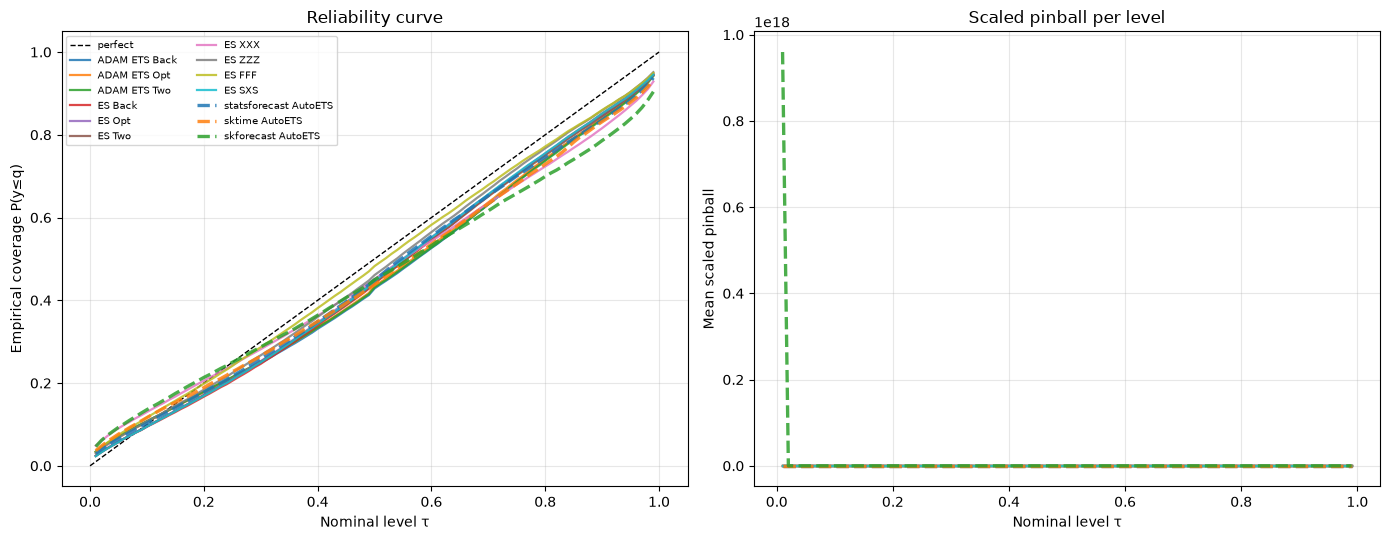

In [14]:
# Reliability curve (empirical coverage vs nominal) + per-level pinball
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
for j, name in enumerate(dist_methods):
    cov = np.nanmean(_cov[j], axis=0)
    if np.all(np.isnan(cov)):
        continue
    is_smooth = not name.endswith("AutoETS")
    ax[0].plot(quantile_levels, cov, lw=1.6 if is_smooth else 2.4,
               ls="-" if is_smooth else "--", alpha=0.85, label=name)
    ax[1].plot(quantile_levels, np.nanmean(_pin[j], axis=0), lw=1.6 if is_smooth else 2.4,
               ls="-" if is_smooth else "--", alpha=0.85, label=name)
ax[0].set(title="Reliability curve", xlabel="Nominal level \u03c4", ylabel="Empirical coverage P(y\u2264q)")
ax[1].set(title="Scaled pinball per level", xlabel="Nominal level \u03c4", ylabel="Mean scaled pinball")
ax[0].legend(fontsize=7, ncol=2); ax[0].grid(alpha=0.3); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
